# 08 — Evaluación de Submissions vs Datos Reales (período de test)

Descarga los **valores reales de 2024** (mismo período que los submissions) desde Yahoo Finance
y calcula el **RMSE final de test** para cada submission.

| Índice | Ticker real |
|--------|-------------|
| Index_A | NASDAQ-100 (`^NDX`) |
| Index_B | S&P 500 (`^GSPC`) |
| Index_C | Commodity ETF (`DBC`) |
| Index_D | Reconstruido: Index_A lag-3 + ruido |
| Index_E | MSCI World (`URTH`) |
| Index_F | Bitcoin (`BTC-USD`) |

**Requisito**: `pip install yfinance`

In [10]:
import sys, os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")

sys.path.insert(0, ".")
from utils import load_data, compute_rmse, compute_rmse_per_index, INDEX_COLS

try:
    import yfinance as yf
except ImportError:
    raise ImportError("Ejecuta: pip install yfinance")

data       = load_data()
test_dates = data["test_dates"].index          # fechas 2024 a evaluar

SUBMISSIONS_DIR = "submissions"
print(f"Período de test : {test_dates[0].date()} → {test_dates[-1].date()}  ({len(test_dates)} días)")

Período de test : 2024-01-01 → 2024-12-31  (262 días)


## 1 — Descarga de valores reales de test (2024)

In [11]:
TICKERS = {
    "Index_A": "^NDX",
    "Index_B": "^GSPC",
    "Index_C": "DBC",
    "Index_E": "URTH",
    "Index_F": "BTC-USD",
}

TEST_START = str(test_dates[0].date())
TEST_END   = str((test_dates[-1] + pd.Timedelta(days=1)).date())  # yfinance excluye end

raw = {}
for col, ticker in TICKERS.items():
    print(f"  Descargando {ticker} ...", end=" ", flush=True)
    df = yf.download(ticker, start=TEST_START, end=TEST_END, auto_adjust=True, progress=False)
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    s = df["Close"].dropna()
    s.index = pd.to_datetime(s.index).tz_localize(None)
    raw[col] = s.reindex(test_dates).ffill().bfill()
    print(f"OK  ({s.notnull().sum()} filas)")

# Index_D: reconstruir como Index_A lag-3 + ruido pequeño (igual que en generate_fake_data)
np.random.seed(42)
A_arr = raw["Index_A"].values
lag   = 3
D_arr = np.concatenate([np.full(lag, A_arr[0]), A_arr[:-lag]])
D_arr = D_arr * (1 + 0.005 * np.random.randn(len(D_arr)))
raw["Index_D"] = pd.Series(D_arr, index=test_dates)

test_real = pd.DataFrame(raw, columns=INDEX_COLS)
print(f"\ntest_real shape: {test_real.shape}")
print(f"Nulos: {test_real.isnull().sum().sum()}")
test_real.head(3)

  Descargando ^NDX ... OK  (252 filas)
  Descargando ^GSPC ... OK  (252 filas)
  Descargando DBC ... OK  (252 filas)
  Descargando URTH ... OK  (252 filas)
  Descargando BTC-USD ... OK  (366 filas)

test_real shape: (262, 6)
Nulos: 0


,Index_A,Index_B,Index_C,Index_D,Index_E,Index_F
Date,,,,,,
2024-01-01,16543.939453,4742.830078,20.076418,16585.027497,127.924889,44167.332031
2024-01-02,16543.939453,4742.830078,20.076418,16532.502272,127.924889,44957.968750
2024-01-03,16368.490234,4704.810059,20.333570,16597.516053,126.896912,42848.175781


## 2 — Carga de submissions

In [12]:
submissions = {}
for fname in sorted(os.listdir(SUBMISSIONS_DIR)):
    if not fname.endswith(".csv"):
        continue
    df = pd.read_csv(os.path.join(SUBMISSIONS_DIR, fname), parse_dates=[0], index_col=0)
    df.index.name = "Date"
    aligned = df.reindex(test_dates)[INDEX_COLS]
    submissions[fname] = aligned
    covered = aligned.notnull().all(axis=1).sum()
    print(f"  {fname}  —  días cubiertos: {covered}/{len(test_dates)}")

print(f"\nTotal submissions: {len(submissions)}")

  submission_01_baseline.csv  —  días cubiertos: 262/262
  submission_02_arima.csv  —  días cubiertos: 262/262
  submission_03_lgbm.csv  —  días cubiertos: 262/262
  submission_05_ensemble.csv  —  días cubiertos: 262/262
  submission_07a_hf_tst.csv  —  días cubiertos: 262/262
  submission_08_mega_ensemble.csv  —  días cubiertos: 262/262

Total submissions: 6


## 3 — RMSE final de test

In [13]:
rows = []
for fname, pred in submissions.items():
    mask = pred.notnull().all(axis=1) & test_real.notnull().all(axis=1)
    r = test_real.loc[mask]
    p = pred.loc[mask]
    if len(r) == 0:
        continue
    rmse_total = compute_rmse(r, p)
    rmse_per   = compute_rmse_per_index(r, p)
    row = {"submission": fname, "RMSE_total": rmse_total, "n_dias": len(r)}
    row.update({f"RMSE_{c}": rmse_per[c] for c in INDEX_COLS})
    rows.append(row)

results = pd.DataFrame(rows).set_index("submission").sort_values("RMSE_total")

print("=" * 70)
print("RANKING — RMSE vs datos reales de TEST (2024)")
print("=" * 70)
display(results.round(2))

RANKING — RMSE vs datos reales de TEST (2024)


,RMSE_total,n_dias,RMSE_Index_A,RMSE_Index_B,RMSE_Index_C,RMSE_Index_D,RMSE_Index_E,RMSE_Index_F
submission,,,,,,,,
submission_07a_hf_tst.csv,5111.66,262,7133.32,1395.07,2.18,6900.87,28.25,15210.28
submission_08_mega_ensemble.csv,5350.82,262,3612.00,904.54,0.59,3631.51,20.19,23936.10
submission_02_arima.csv,5588.74,262,2638.91,752.86,0.77,2594.45,17.31,27528.14
submission_05_ensemble.csv,5652.31,262,2769.53,777.59,0.75,2729.55,18.42,27618.02
submission_01_baseline.csv,5678.31,262,2935.04,821.42,0.72,3016.08,19.50,27277.10
submission_03_lgbm.csv,5749.18,262,2663.58,781.79,0.78,2984.15,17.60,28047.16


## 4 — Ranking visual

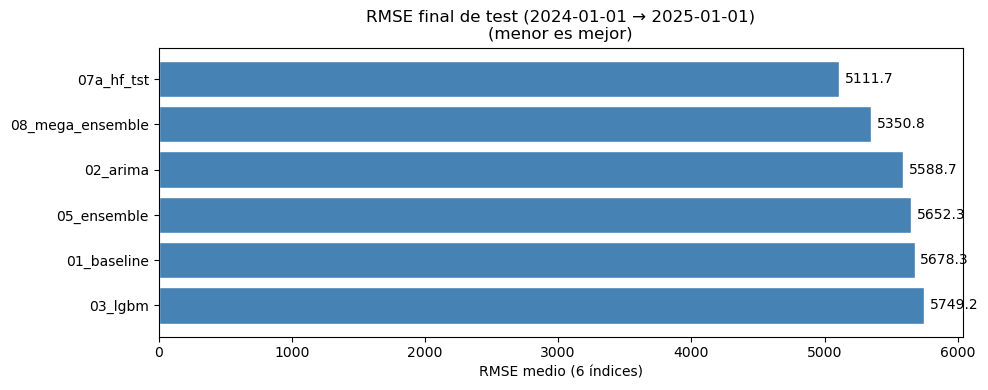


Mejor submission: submission_07a_hf_tst.csv
  → RMSE total = 5,111.66


In [14]:
fig, ax = plt.subplots(figsize=(10, max(3, len(results) * 0.5 + 1)))
labels = [s.replace("submission_", "").replace(".csv", "") for s in results.index]
bars = ax.barh(labels, results["RMSE_total"], color="steelblue", edgecolor="white")
ax.bar_label(bars, fmt="%.1f", padding=4)
ax.set_xlabel("RMSE medio (6 índices)")
ax.set_title(f"RMSE final de test ({TEST_START} → {TEST_END})\n(menor es mejor)")
ax.invert_yaxis()
plt.tight_layout()
plt.savefig("eval_rmse_ranking_test.png", dpi=100)
plt.show()

best = results.index[0]
print(f"\nMejor submission: {best}")
print(f"  → RMSE total = {results.loc[best, 'RMSE_total']:,.2f}")

## 5 — RMSE desglosado por índice

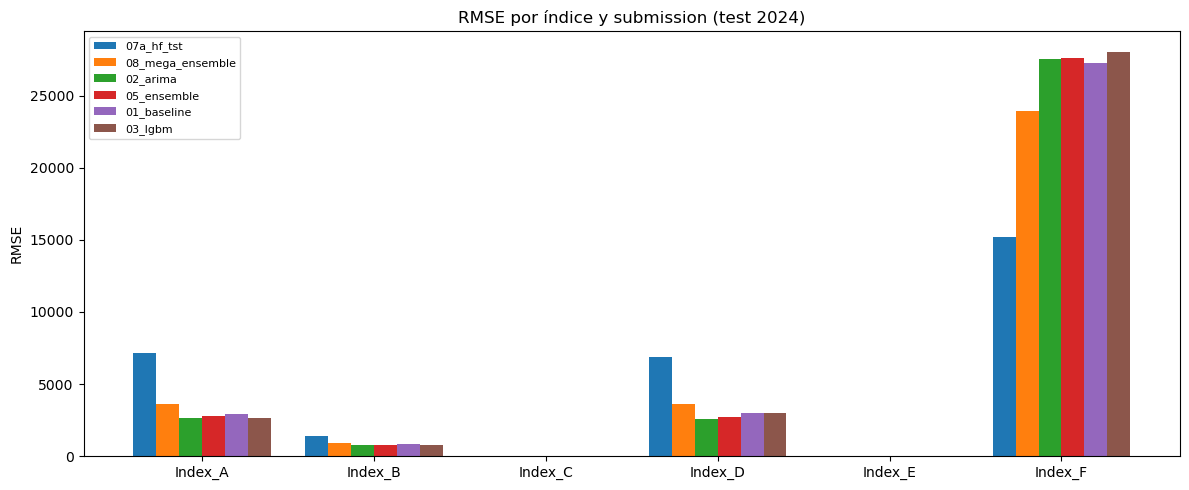

In [15]:
fig, ax = plt.subplots(figsize=(12, 5))
x     = np.arange(len(INDEX_COLS))
width = 0.8 / max(len(results), 1)
for i, (sub, row) in enumerate(results.iterrows()):
    label = sub.replace("submission_", "").replace(".csv", "")
    vals  = [row[f"RMSE_{c}"] for c in INDEX_COLS]
    ax.bar(x + i * width, vals, width, label=label)
ax.set_xticks(x + width * (len(results) - 1) / 2)
ax.set_xticklabels(INDEX_COLS)
ax.set_ylabel("RMSE")
ax.set_title("RMSE por índice y submission (test 2024)")
ax.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.show()

## 6 — Predicción vs valores reales (mejor submission)

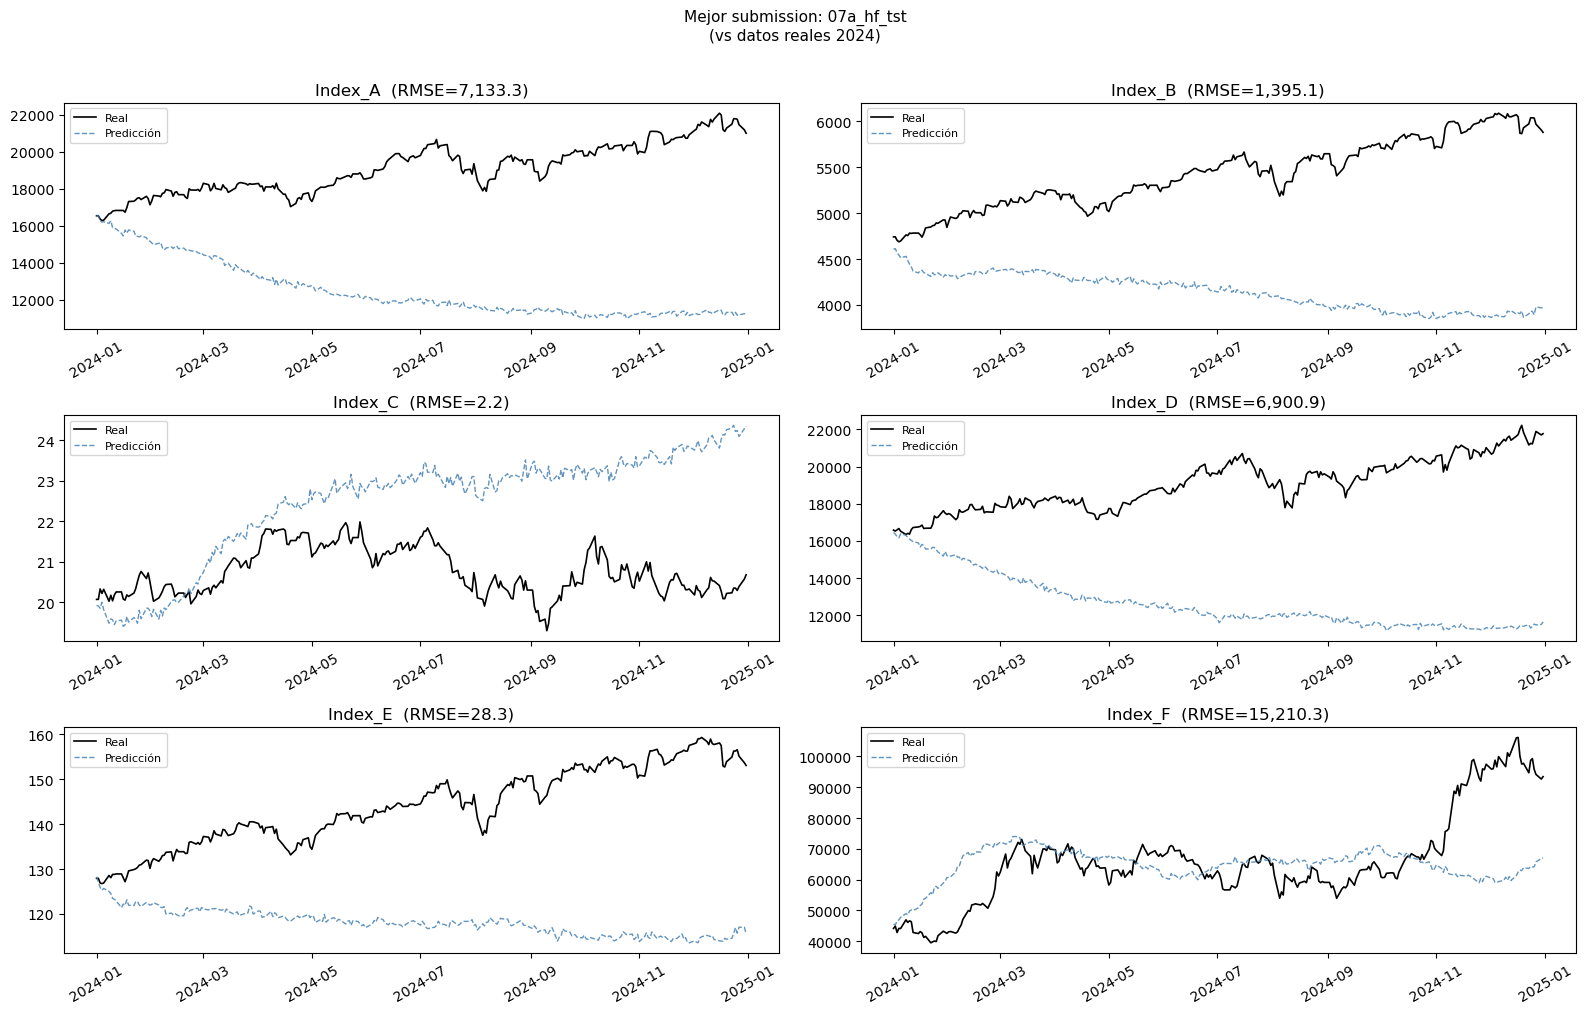

In [16]:
best_pred = submissions[best].reindex(test_dates)

fig, axes = plt.subplots(3, 2, figsize=(16, 10))
for ax, col in zip(axes.flatten(), INDEX_COLS):
    ax.plot(test_dates, test_real[col], label="Real", lw=1.2, color="black")
    ax.plot(test_dates, best_pred[col], label="Predicción", lw=1.0,
            linestyle="--", color="steelblue", alpha=0.85)
    mask = best_pred[col].notnull() & test_real[col].notnull()
    rmse_col = np.sqrt(((test_real.loc[mask, col] - best_pred.loc[mask, col]) ** 2).mean())
    ax.set_title(f"{col}  (RMSE={rmse_col:,.1f})")
    ax.legend(fontsize=8)
    ax.tick_params(axis="x", rotation=30)
plt.suptitle(f"Mejor submission: {best.replace('submission_','').replace('.csv','')}\n(vs datos reales 2024)",
             fontsize=11, y=1.01)
plt.tight_layout()
plt.savefig("eval_best_vs_real_test.png", dpi=100)
plt.show()

## 7 — MAPE (%) — perspectiva porcentual

In [17]:
mape_rows = []
for fname, pred in submissions.items():
    mask = pred.notnull().all(axis=1) & test_real.notnull().all(axis=1)
    r = test_real.loc[mask]; p = pred.loc[mask]
    if len(r) == 0: continue
    mape_per  = (np.abs((r.values - p.values) / r.values)).mean(axis=0) * 100
    row = {"submission": fname, "MAPE_total_%": round(mape_per.mean(), 3)}
    row.update({f"MAPE_{c}_%": round(v, 3) for c, v in zip(INDEX_COLS, mape_per)})
    mape_rows.append(row)

mape_df = pd.DataFrame(mape_rows).set_index("submission").sort_values("MAPE_total_%")
print("=== MAPE (%) — test 2024 ===")
display(mape_df)

=== MAPE (%) — test 2024 ===


,MAPE_total_%,MAPE_Index_A_%,MAPE_Index_B_%,MAPE_Index_C_%,MAPE_Index_D_%,MAPE_Index_E_%,MAPE_Index_F_%
submission,,,,,,,
submission_02_arima.csv,13.340,11.531,11.725,2.762,11.271,10.194,32.556
submission_05_ensemble.csv,13.810,12.267,12.212,2.692,12.015,10.992,32.683
submission_03_lgbm.csv,13.961,11.631,12.248,2.805,13.281,10.384,33.418
submission_01_baseline.csv,14.413,13.220,13.110,2.555,13.658,11.835,32.096
submission_08_mega_ensemble.csv,14.769,16.463,14.446,2.349,16.533,12.180,26.645
submission_07a_hf_tst.csv,21.881,33.726,23.050,9.018,32.618,17.608,15.264


## 8 — Resumen final

In [18]:
print("\n" + "="*60)
print("RESUMEN FINAL — EVALUACIÓN EN TEST REAL (2024)")
print("="*60)
print(f"Período evaluado : {test_dates[0].date()} → {test_dates[-1].date()}")
print(f"Días evaluados   : {len(test_dates)}")
print(f"Submissions      : {len(results)}")
print()
print(results[["RMSE_total", "n_dias"]].to_string())
print()
print(f"Mejor modelo (RMSE): {results.index[0]}")
print(f"  → RMSE = {results['RMSE_total'].iloc[0]:,.2f}")
if len(mape_df) > 0:
    print(f"  → MAPE = {mape_df['MAPE_total_%'].iloc[0]:.3f} %")


RESUMEN FINAL — EVALUACIÓN EN TEST REAL (2024)
Período evaluado : 2024-01-01 → 2024-12-31
Días evaluados   : 262
Submissions      : 6

                                  RMSE_total  n_dias
submission                                          
submission_07a_hf_tst.csv        5111.660726     262
submission_08_mega_ensemble.csv  5350.821310     262
submission_02_arima.csv          5588.740271     262
submission_05_ensemble.csv       5652.311233     262
submission_01_baseline.csv       5678.310688     262
submission_03_lgbm.csv           5749.178009     262

Mejor modelo (RMSE): submission_07a_hf_tst.csv
  → RMSE = 5,111.66
  → MAPE = 13.340 %
